# Evaluate Model

Evaluate RT-DETR v2 models on the real test set.

**Model sources:**

- **W&B artifacts**: Load specific checkpoints (e.g. best mAP from a training round)
- **HF Hub**: Load published models from repo branches

**Metrics:**

1. mAP (COCO mAP@50:95, mAP@50, mAP@75)
2. Center-distance P/R/F1 at various distance thresholds
3. Confidence threshold sweep (P/R/F1 vs score threshold)
4. Visual prediction browsing

## Configuration

In [1]:
%load_ext autoreload
%autoreload 2

import torch
from dotenv import load_dotenv

from datasets import load_dataset

from moku.dataset import CATEGORIES, ID_TO_CATEGORY
from moku.evaluation import (
    evaluate_center_distance,
    evaluate_map,
    sweep_confidence_threshold,
)
from moku.runs import list_wandb_model_artifacts, load_model_from_wandb
from moku.model import collate_fn, make_eval_transform
from moku.viz import plot_model_comparison, plot_threshold_sweep

load_dotenv()

HF_DATASET = "kaya-go/moku-v2"

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: mps


## Load Datasets


In [2]:
ds_real = load_dataset(HF_DATASET, "real")
print(ds_real)

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 382
    })
    validation: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 53
    })
    test: Dataset({
        features: ['image', 'image_id', 'width', 'height', 'source_dataset', 'objects'],
        num_rows: 50
    })
})


## Load Models from W&B

List available model artifacts and select which ones to evaluate.

In [3]:
# List available model artifacts from W&B
artifacts_df = list_wandb_model_artifacts()

cols = [
    c
    for c in ["name", "version", "aliases", "run", "eval_map", "eval_map_50", "epoch", "size_mb"]
    if c in artifacts_df.columns
]
display(artifacts_df[cols].sort_values("eval_map", ascending=False).reset_index(drop=True))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


,name,version,aliases,run,eval_map,eval_map_50,epoch,size_mb
0,model-r5_lr4e-4_linear500:v51,v51,[latest],r5_lr4e-4_linear500,0.607520,0.923377,413.0,80.5
1,model-r6_lr3e-4_cosmin1000:v27,v27,[latest],r6_lr3e-4_cosmin1000,0.595749,0.914674,730.0,80.5
2,model-r5_lr3e-4_cos500:v56,v56,[latest],r5_lr3e-4_cos500,0.584135,0.891032,318.0,80.5
3,model-r6_lr3e-4_linear1000:v47,v47,[latest],r6_lr3e-4_linear1000,0.580296,0.888961,916.0,80.5
4,model-r6_lr4e-4_linear1000:v40,v40,[latest],r6_lr4e-4_linear1000,0.563961,0.908895,807.0,80.5
5,model-r6_lr4e-4_cosmin1000:v37,v37,[latest],r6_lr4e-4_cosmin1000,0.524324,0.777648,770.0,80.5
6,model-r7_lr1e-4_linear500:v10,v10,[latest],r7_lr1e-4_linear500,0.357794,0.590910,31.0,80.5
7,model-r7_lr3e-4_cosmin500:v14,v14,[latest],r7_lr3e-4_cosmin500,0.343711,0.586942,34.0,80.5
8,model-r7_lr3e-4_linear500:v11,v11,[latest],r7_lr3e-4_linear500,0.316776,0.533406,20.0,80.5
9,model-r7_lr5e-4_linear500:v6,v6,[latest],r7_lr5e-4_linear500,0.311998,0.497071,12.0,80.5


Select artifacts to evaluate. Set the `ARTIFACTS` dict below (label → artifact name).

In [4]:
artifacts_df["name"].tolist()

['model-r7_lr3e-4_cosmin500:v14',
 'model-r7_lr3e-4_linear500:v11',
 'model-r7_lr5e-4_linear500:v6',
 'model-r7_lr1e-4_linear500:v10',
 'model-r6_lr3e-4_cosmin1000:v27',
 'model-r6_lr4e-4_cosmin1000:v37',
 'model-r6_lr3e-4_linear1000:v47',
 'model-r6_lr4e-4_linear1000:v40',
 'model-r5_lr4e-4_linear500:v51',
 'model-r5_lr3e-4_cos500:v56']

In [5]:
from tqdm.auto import tqdm

# Set which artifacts to evaluate (base names, :latest is appended automatically)
ARTIFACTS = [
    "model-r5_lr4e-4_linear500",
    "model-r6_lr4e-4_cosmin1000",
    "model-r7_lr3e-4_cosmin500",
    "model-r7_lr3e-4_linear500",
    "model-r7_lr5e-4_linear500",
    "model-r7_lr1e-4_linear500",
]

# Load models
models = {}
for name in tqdm(ARTIFACTS, desc="Loading models", leave=False):
    ip, model = load_model_from_wandb(f"{name}:latest")
    models[name] = {"ip": ip, "model": model}

print(f"Loaded {len(models)} models: {list(models.keys())}")

Loading models:   0%|          | 0/6 [00:00<?, ?it/s]

wandb: Downloading large artifact 'model-r5_lr4e-4_linear500:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:00.3 (265.0MB/s)


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

wandb: Downloading large artifact 'model-r6_lr4e-4_cosmin1000:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:00.3 (286.7MB/s)


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

...

wandb: Downloading large artifact 'model-r7_lr5e-4_linear500:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:04.9 (15.8MB/s)


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

wandb: Downloading large artifact 'model-r7_lr1e-4_linear500:latest', 76.78MB. 3 files...
wandb:   3 of 3 files downloaded.  
Done. 00:00:04.7 (16.3MB/s)


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Loaded 6 models: ['model-r5_lr4e-4_linear500', 'model-r6_lr4e-4_cosmin1000', 'model-r7_lr3e-4_cosmin500', 'model-r7_lr3e-4_linear500', 'model-r7_lr5e-4_linear500', 'model-r7_lr1e-4_linear500']


## Evaluate on Real Validation

Same metrics as above, but on the validation set.

In [18]:
import numpy as np
import pandas as pd

THRESHOLD = 0.05

# ── Run both evaluations on validation set ──
val_metrics_map = {}
val_cd_results = {}

for label, entry in models.items():
    ds_real.set_transform(make_eval_transform(entry["ip"]))
    val_metrics_map[label] = evaluate_map(
        model=entry["model"],
        dataset=ds_real["validation"],
        image_processor=entry["ip"],
        batch_size=8,
    )
    val_cd_results[label] = evaluate_center_distance(
        model=entry["model"],
        dataset=ds_real["validation"],
        image_processor=entry["ip"],
        batch_size=8,
        threshold=THRESHOLD,
    )

# ── Build summary DataFrame ──
val_summary_rows = []
for label in models:
    row = {"model": label}
    row["mAP@50"] = val_metrics_map[label].get("map_50", float("nan"))
    cd = val_cd_results[label]
    row["corner_R"] = cd["per_class"]["board_corner"]["thresholds"]["2%"]["recall"]
    stone_f1s = [cd["per_class"][c]["thresholds"]["2%"]["f1"] for c in ("black_stone", "white_stone")]
    row["stone_F1"] = np.mean(stone_f1s)
    val_summary_rows.append(row)

val_summary_df = pd.DataFrame(val_summary_rows).sort_values("mAP@50", ascending=False).reset_index(drop=True)
val_summary_df

,model,mAP@50,corner_R,stone_F1
0,model-r5_lr4e-4_linear500,0.920900,0.7857,0.91125
1,model-r6_lr4e-4_cosmin1000,0.775648,0.7500,0.95410
2,model-r7_lr3e-4_cosmin500,0.587931,0.3214,0.42785
3,model-r7_lr1e-4_linear500,0.552159,0.0357,0.30335
4,model-r7_lr3e-4_linear500,0.539590,0.0357,0.39100
5,model-r7_lr5e-4_linear500,0.500682,0.0714,0.40890


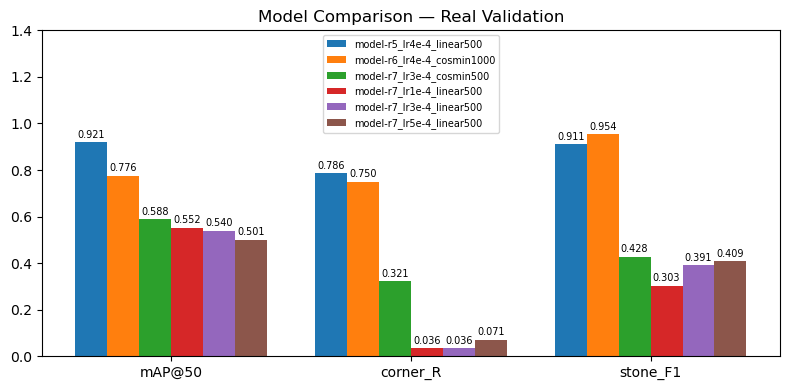

In [19]:
color_map = plot_model_comparison(val_summary_df, title="Model Comparison — Real Validation")

## Evaluate on Real Test

Run mAP and center-distance evaluation on the real test set, then plot the 3 key metrics:

| Metric | What it measures |
|--------|------------------|
| **mAP@50** | Overall detection quality (COCO IoU≥0.50) |
| **corner_R** | `board_corner` recall @ 2% center-distance — need 4/4 for homography |
| **stone_F1** | Macro F1 of `black_stone` + `white_stone` @ 2% center-distance |

In [20]:
import numpy as np
import pandas as pd

THRESHOLD = 0.05

# ── Run both evaluations ──
metrics_map = {}
cd_results = {}

for label, entry in models.items():
    ds_real.set_transform(make_eval_transform(entry["ip"]))
    metrics_map[label] = evaluate_map(
        model=entry["model"],
        dataset=ds_real["test"],
        image_processor=entry["ip"],
        batch_size=8,
    )
    cd_results[label] = evaluate_center_distance(
        model=entry["model"],
        dataset=ds_real["test"],
        image_processor=entry["ip"],
        batch_size=8,
        threshold=THRESHOLD,
    )

# ── Build summary DataFrame ──
summary_rows = []
for label in models:
    row = {"model": label}
    row["mAP@50"] = metrics_map[label].get("map_50", float("nan"))
    cd = cd_results[label]
    row["corner_R"] = cd["per_class"]["board_corner"]["thresholds"]["2%"]["recall"]
    stone_f1s = [cd["per_class"][c]["thresholds"]["2%"]["f1"] for c in ("black_stone", "white_stone")]
    row["stone_F1"] = np.mean(stone_f1s)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("mAP@50", ascending=False).reset_index(drop=True)
summary_df

,model,mAP@50,corner_R,stone_F1
0,model-r6_lr4e-4_cosmin1000,0.806959,0.8571,0.82030
1,model-r5_lr4e-4_linear500,0.785377,0.6429,0.85005
2,model-r7_lr3e-4_cosmin500,0.409714,0.3929,0.55645
3,model-r7_lr1e-4_linear500,0.365989,0.0714,0.41070
4,model-r7_lr3e-4_linear500,0.327639,0.1786,0.45590
5,model-r7_lr5e-4_linear500,0.301981,0.2500,0.51100


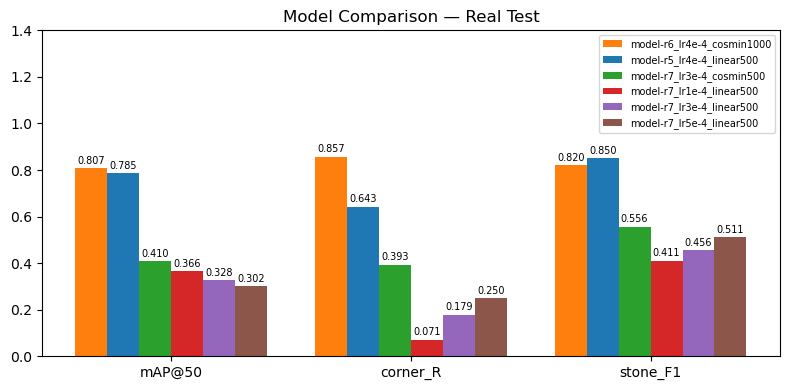

{'model-r5_lr4e-4_linear500': (np.float64(0.12156862745098039),
  np.float64(0.4666666666666667),
  np.float64(0.7058823529411765),
  np.float64(1.0)),
 'model-r6_lr4e-4_cosmin1000': (np.float64(1.0),
  np.float64(0.4980392156862745),
  np.float64(0.054901960784313725),
  np.float64(1.0)),
 'model-r7_lr3e-4_cosmin500': (np.float64(0.17254901960784313),
  np.float64(0.6274509803921569),
  np.float64(0.17254901960784313),
  np.float64(1.0)),
 'model-r7_lr1e-4_linear500': (np.float64(0.8392156862745098),
  np.float64(0.15294117647058825),
  np.float64(0.1568627450980392),
  np.float64(1.0)),
 'model-r7_lr3e-4_linear500': (np.float64(0.5803921568627451),
  np.float64(0.403921568627451),
  np.float64(0.7411764705882353),
  np.float64(1.0)),
 'model-r7_lr5e-4_linear500': (np.float64(0.5490196078431373),
  np.float64(0.33725490196078434),
  np.float64(0.29411764705882354),
  np.float64(1.0))}

In [21]:
plot_model_comparison(summary_df, title="Model Comparison — Real Test", color_map=color_map)

## Confidence Threshold Sweep

Find the optimal confidence threshold by sweeping P/R/F1 (center-distance @2%) vs score threshold.
Inference runs only once per model — threshold filtering is applied post-hoc.

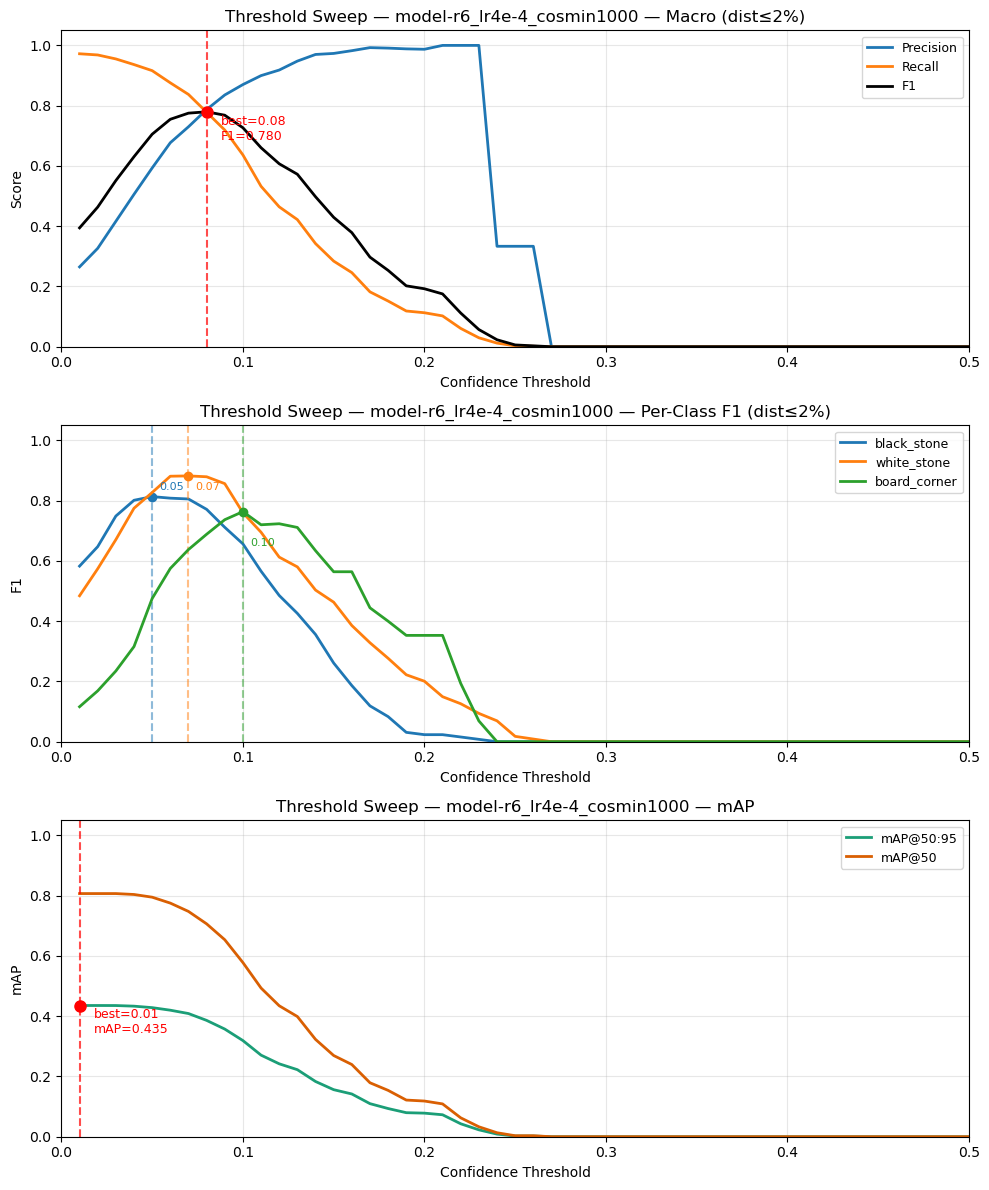

In [22]:
SWEEP_MODEL = "model-r6_lr4e-4_cosmin1000"

sweep_entry = models[SWEEP_MODEL]
ds_real.set_transform(make_eval_transform(sweep_entry["ip"]))
sweep = sweep_confidence_threshold(
    model=sweep_entry["model"],
    dataset=ds_real["test"],
    image_processor=sweep_entry["ip"],
    batch_size=8,
    distance_threshold=0.02,
)
plot_threshold_sweep(sweep, title=f"Threshold Sweep — {SWEEP_MODEL}")

## Browse Predictions

Interactive widget to browse model predictions on dataset samples.


In [11]:
from moku.viz import browse_predictions

# Build model registry for browsing
all_models = {}
for label, entry in models.items():
    all_models[label] = {"model": entry["model"].to(device), "image_processor": entry["ip"]}

# Build dataset registry
ds_synthetic = load_dataset(HF_DATASET, "synthetic")
all_datasets = {"Real": ds_real, "Synthetic": ds_synthetic}

browse_predictions(all_models, all_datasets, threshold=THRESHOLD)